<a href="https://colab.research.google.com/github/cavalcantiju/ex2_DS_alura/blob/main/ex2_DS_alura.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [55]:
import pandas as pd

In [56]:
dados = pd.read_csv('/content/usina.csv')

In [57]:
dados.head()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


In [58]:
x = dados.drop(columns = 'PE')
y = dados['PE']


In [59]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state= 230)

len(x_train), len(x_test), len(y_train), len(y_test)

(6697, 2871, 6697, 2871)

In [60]:
df_train = pd.DataFrame(x_train)
df_train['PE'] = y_train
df_train.head()

,AT,V,AP,RH,PE
3522,11.09,40.43,1025.47,74.97,490.96
4271,14.20,40.92,1022.26,71.71,460.42
6811,7.03,41.74,1021.92,86.44,486.91
1801,23.82,48.92,1010.48,44.45,446.85
8036,16.16,52.05,1013.19,75.37,463.09


In [61]:
from statsmodels.formula.api import ols
import statsmodels.api as sm

x_train = sm.add_constant(x_train)

In [62]:
explicativas_1 = ['const', 'AT', 'V', 'AP', 'RH']

explicativas_2 = ['const', 'V', 'AP', 'RH']



In [63]:
vif_1 = pd.DataFrame()
vif_1["variavel"] = explicativas_1

vif_1["vif"] = [variance_inflation_factor(x_train[explicativas_1],
                                          i) for i in range(len(explicativas_1))]
vif_1

,variavel,vif
0,const,44603.788615
1,AT,6.034363
2,V,3.954998
3,AP,1.468530
4,RH,1.717508


In [64]:
vif_2 = pd.DataFrame()
vif_2["variavel"] = explicativas_2

vif_2["vif"] = [variance_inflation_factor(x_train[explicativas_2],
                                          i) for i in range(len(explicativas_2))]
vif_2

,variavel,vif
0,const,36577.789437
1,V,1.327768
2,AP,1.215769
3,RH,1.104508


In [65]:
modelo1 = sm.OLS(y_train, x_train).fit()
print(modelo1.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 2.191e+04
Date:                Tue, 17 Mar 2026   Prob (F-statistic):               0.00
Time:                        18:46:59   Log-Likelihood:                -19662.
No. Observations:                6697   AIC:                         3.933e+04
Df Residuals:                    6692   BIC:                         3.937e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        446.1042     11.769     37.905      0.0

In [66]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score

print("R²:")
print("Modelo 1: ", modelo1.rsquared)

R²:
Modelo 1:  0.9290523664869893


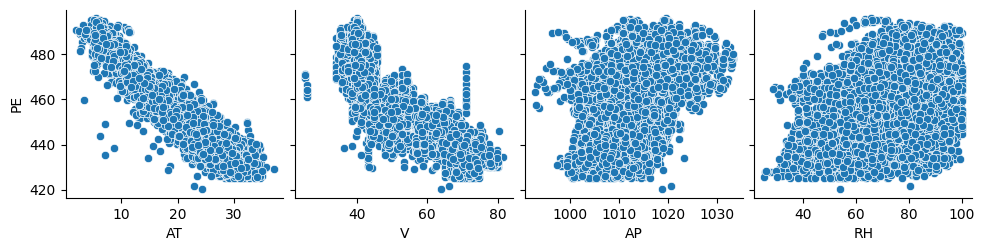

In [67]:
sns.pairplot(dados, y_vars = 'PE', x_vars = ['AT', 'V', 'AP', 'RH'])

In [68]:
modelo2 = sm.OLS(y_train, x_train[explicativas_2]).fit()
print(modelo2.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.808
Model:                            OLS   Adj. R-squared:                  0.808
Method:                 Least Squares   F-statistic:                     9370.
Date:                Tue, 17 Mar 2026   Prob (F-statistic):               0.00
Time:                        18:47:00   Log-Likelihood:                -23001.
No. Observations:                6697   AIC:                         4.601e+04
Df Residuals:                    6693   BIC:                         4.604e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -88.0285     17.545     -5.017      0.0

In [70]:
import plotly.express as px

predict1_train = modelo1.predict(x_train)

fig = px.scatter(x= predict1_train, y = y_train,
                 title = 'Previsão vs Real',
                 labels = {'x': 'previsto', 'y': 'real'})
fig.show()

<Axes: title={'center': 'Residuos x Previsao'}, xlabel='Previsão do preço da casa', ylabel='Residuos'>

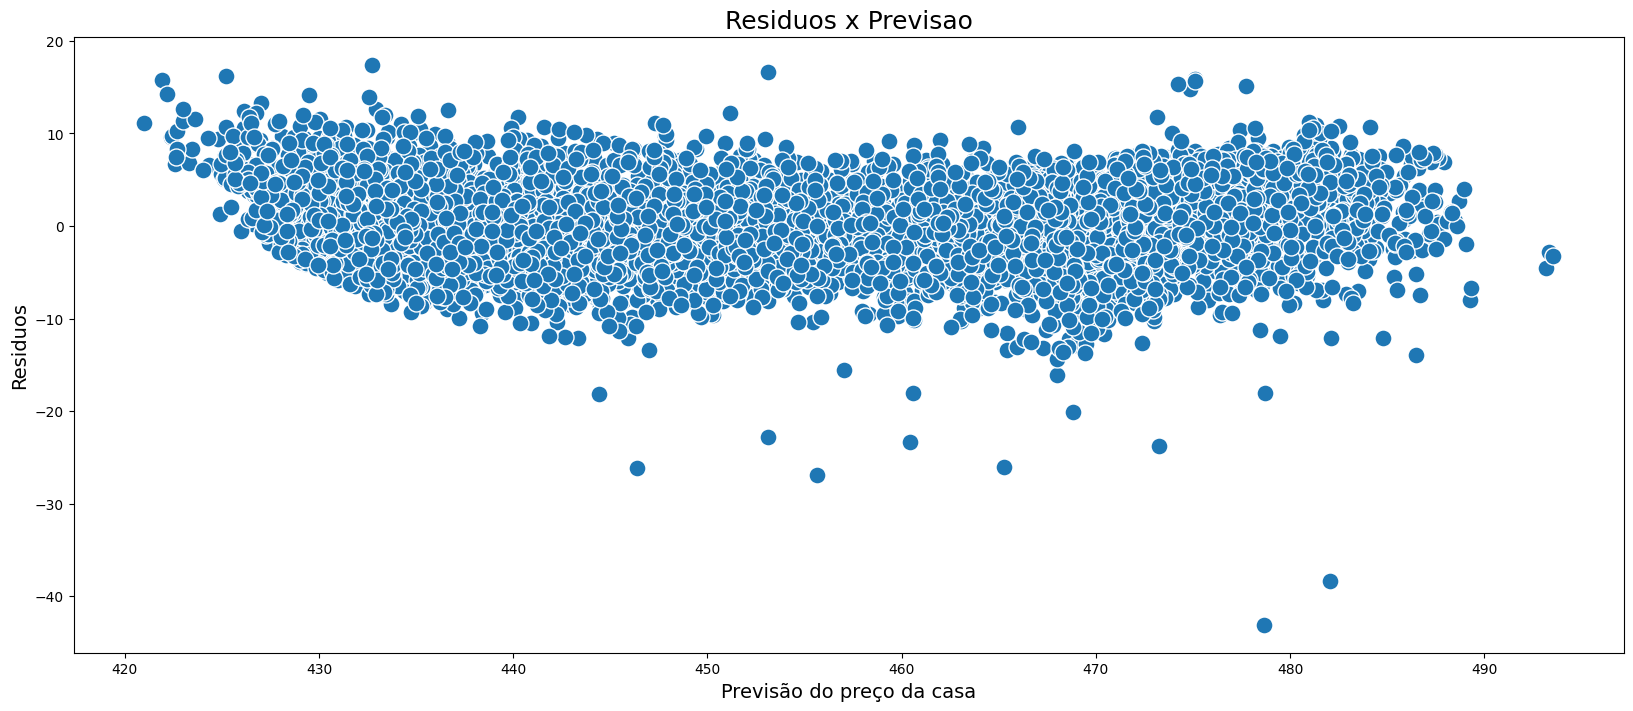

In [71]:
residuos = modelo1.resid
ax = sns.scatterplot(x= predict1_train, y = residuos, s=150)
ax.figure.set_size_inches(20, 8)
ax.set_title('Residuos x Previsao', fontsize=18)
ax.set_xlabel('Previsão do preço da casa', fontsize = 14)
ax.set_ylabel('Residuos', fontsize = 14)
ax

In [72]:
predict2_train = modelo2.predict(x_train[explicativas_2])
fig = px.scatter(x= predict2_train, y = y_train,
                 title = 'Previsão vs Real',
                 labels = {'x': 'previsto', 'y': 'real'})
fig.show()

<Axes: title={'center': 'Residuos x Previsao'}, xlabel='Previsão do preço da casa', ylabel='Residuos'>

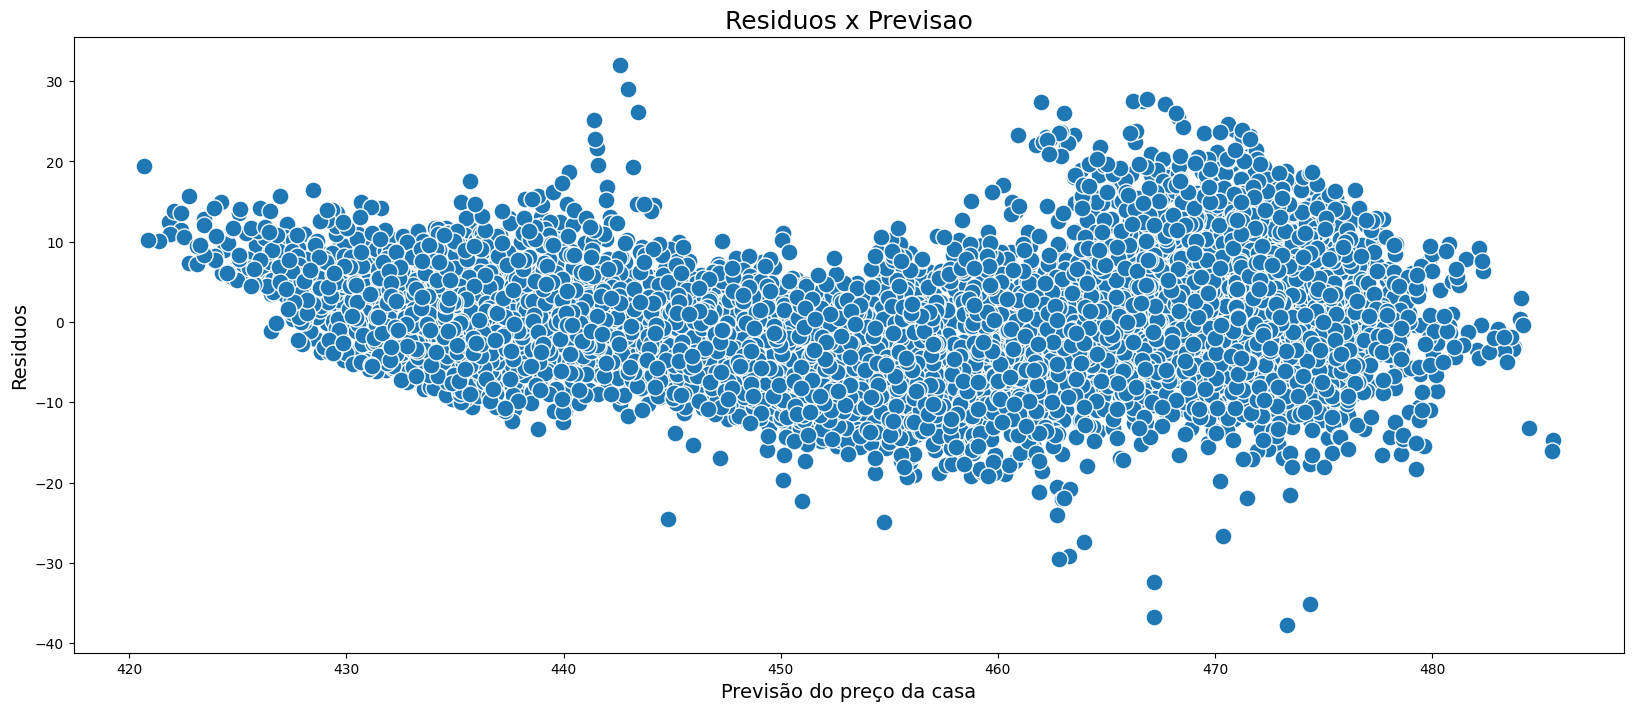

In [73]:
residuos = modelo2.resid
ax = sns.scatterplot(x= predict2_train, y = residuos, s=150)
ax.figure.set_size_inches(20, 8)
ax.set_title('Residuos x Previsao', fontsize=18)
ax.set_xlabel('Previsão do preço da casa', fontsize = 14)
ax.set_ylabel('Residuos', fontsize = 14)
ax